In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie
Makie.inline!(true)
using CSV, DataFrames, Statistics

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [136]:
rods2DChemotaxis = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :isSource => Bool, 
        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64

        # :xs => Float64,
        # :ys => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :DSource => Float64,
        :delta => Float64 
    ),

    medium = Dict(
        :mm => Float64
    ),

    agentODE = quote

        # R_source = 1.0  # μm — size of source
        # R_source = 2.0
        # R_source = 5.0
        # R_source = 10.0
        # R_source = 20.0
        # R_source = 0.0

        # r = sqrt((x - xs)^2 + (y - ys)^2)
        # mm = 1.0 * exp(-max(0.0, r - R_source) / 10.0)
        # mm = 10.0 * exp(-max(0.0, r - R_source) / 10.0)
        # mm = 100.0 * exp(-max(0.0, r - R_source) / 10.0)

        M = mm


        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = active * vx  #Change position acording to constant speed afected by forces
        dt(y) = active * vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote
        if isSource
            active = false

            # σ = sqrt(2 * DSource / dt)

            # vx = σ * randn()
            # vy = σ * randn()
            vx = v * cos(theta)
            vy = v * sin(theta)
            x += vx * dt
            y += vx * dt
            theta += sqrt(2 * DSource * dt) * randn()
            mm += S  
        else

            v_run = v
            v_tumble = 0.25 

            speed = active ? v_run : v_tumble

            Dr_tumble = 6.2      
            Dr_total = active ? Dr_run : Dr_tumble

            if active 
                λ = ωFrec*exp(-G)
                P = 1 - exp(-λ * dt)
                
            else
                λ = ωFrec*exp(G)
                P = 1 - exp(-λ * dt)  
                
            end


            if active 
                λrt = ωFrec*exp(-G) 

                P_rt = 1 - exp(-λrt * dt)
                P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
                else     #Si rate baixa 
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
                end

            elseif !active
                λtr = ωFrec*exp(G) 
                P_tr = 1 - exp(-λtr * dt)
                P = rand()

                if P < P_tr
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                else
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()
                end
            end
        end

        # if x < simBox[1,1]*0.9
        #     x = simBox[1,1]*0.9 + 0.01 
        #     # theta = pi - theta   
        # elseif x > simBox[1,2]*0.9
        #     x = simBox[1,2]*0.9 - 0.01 
        #     # theta = pi - theta
        # end
        # if y < simBox[2,1]*0.9
        #     y = simBox[2,1]*0.9 + 0.01
        #     # theta = -theta
        # elseif y > simBox[2,2]*0.9
        #     y = simBox[2,2]*0.9 - 0.01
        #     # theta = -theta
        # end
        # if x < simBox[1,1]*0.9
        #     theta = rand(Uniform(0, π))  # 0 to 180° → points right
        # elseif x > simBox[1,2]*0.9
        #     theta = rand(Uniform(π, 2π))  # 180° to 360° → points left
        # elseif y < simBox[2,1]*0.9
        #     theta = rand(Uniform(π/2, 3π/2))  # 90° to 270° → points up
        # elseif y > simBox[2,2]*0.9
        #     theta = rand(Uniform(-π/2, π/2))  # -90° to 90° → points down
        # end
        # if x < simBox[1,1]*0.9 || x > simBox[1,2]*0.9 || y < simBox[2,1]*0.9 || y > simBox[2,2]*0.9
        #     x = clamp(x, simBox[1,1]*0.9 + 0.01, simBox[1,2]*0.9 - 0.01)
        #     y = clamp(y, simBox[2,1]*0.9 + 0.01, simBox[2,2]*0.9 - 0.01)
        # end

   # X boundaries
        collision = (x ≤ simBox[1,1]) || (x ≥ simBox[1,2]) || (y ≤ simBox[2,1]) || (y ≥ simBox[2,2])

        if collision
            vx = 0.25
            vy = 0.25
            theta = rand(Uniform(0, 2π))
        end


    end,

    mediumODE = quote
        if @mediumInside()
            dt(mm) = DMedium *(@∂2(1, mm)+ @∂2(2, mm)) - delta*mm 
        elseif @mediumBorder(1,-1)
            mm = 0
        elseif @mediumBorder(1,1)
            mm = 0
        elseif @mediumBorder(2,-1)
            mm = 0
        elseif @mediumBorder(2,-1)
            mm = 0
        end
    end,

    neighborsAlg = CBMNeighbors.CellLinked(cellEdge = 4)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	isSource (Bool agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	DSource (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)


UPDATE RULES
mediumODE
 if @mediumInside()

In [142]:
com = Community(
    rods2DChemotaxis,
    N=1,
    dt=0.01,
    # simBox = [-20.0 20.0; -20.0 20.0],
    simBox = [-50.0 50.0; -50.0 50.0],
    NMedium = [100, 100]
    # NMedium = [200, 200]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v = 20.0       #Velocitat neutrophil tambe
com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1

# com.DMedium = 100
# com.DMedium = 10
com.DMedium = 1
# com.DMedium = 0.1
# com.DMedium = 0.01
# com.DMedium = 0.001
# com.DMedium = 0.0001

com.DSource = 0.063
com.delta = 0.01

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

# com.τm = 5.0
# com.τm = 10.0
com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.x = rand(Uniform(com.simBox[1,:]...),com.N)
com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

src = 1

com.isSource .= false
com.isSource[src] = true

com.active .= true 
com.active[src] = false   

com.S .= 0.0
# com.xs .= 0.0
# com.ys .= 0.0
# com.xs[src] = com.x[src]
# com.ys[src] = com.y[src]

# com.S[src] = 0.0025
# com.S[src] = 0.016
com.S[src] = 0.1
# com.S[src] = 100
# com.S[src] = 1000


0.1

In [143]:
outfile = "prey_test.csv"
data = DataFrame(
    step = Int[],
    id = Int[],
    x = Float64[],
    y = Float64[],
    theta = Float64[],
    l = Float64[],
    d = Float64[],
    active = Bool[],
    isSource = Bool[],
    mm_grid = Any[]
)



steps = 10000
# saveEach = 10
loadToPlatform!(com, preallocateAgents=1)       #Preallocate agents = number of agents in community
com.mm = zeros(Float64, com.NMedium...)  

for step in 1:steps 
    step!(com)
    # if step % saveEach == 0
        mm_grid_flat = copy(vec(com.mm))

        for i in 1:com.N
            push!(data, (
                step, 
                i,
                com.x[i],
                com.y[i],
                com.theta[i],
                com.l[i],
                com.d[i],
                com.active[i],
                com.isSource[i],
                mm_grid_flat
            ))
        end
    
end

CSV.write(outfile, data)

"prey_test.csv"

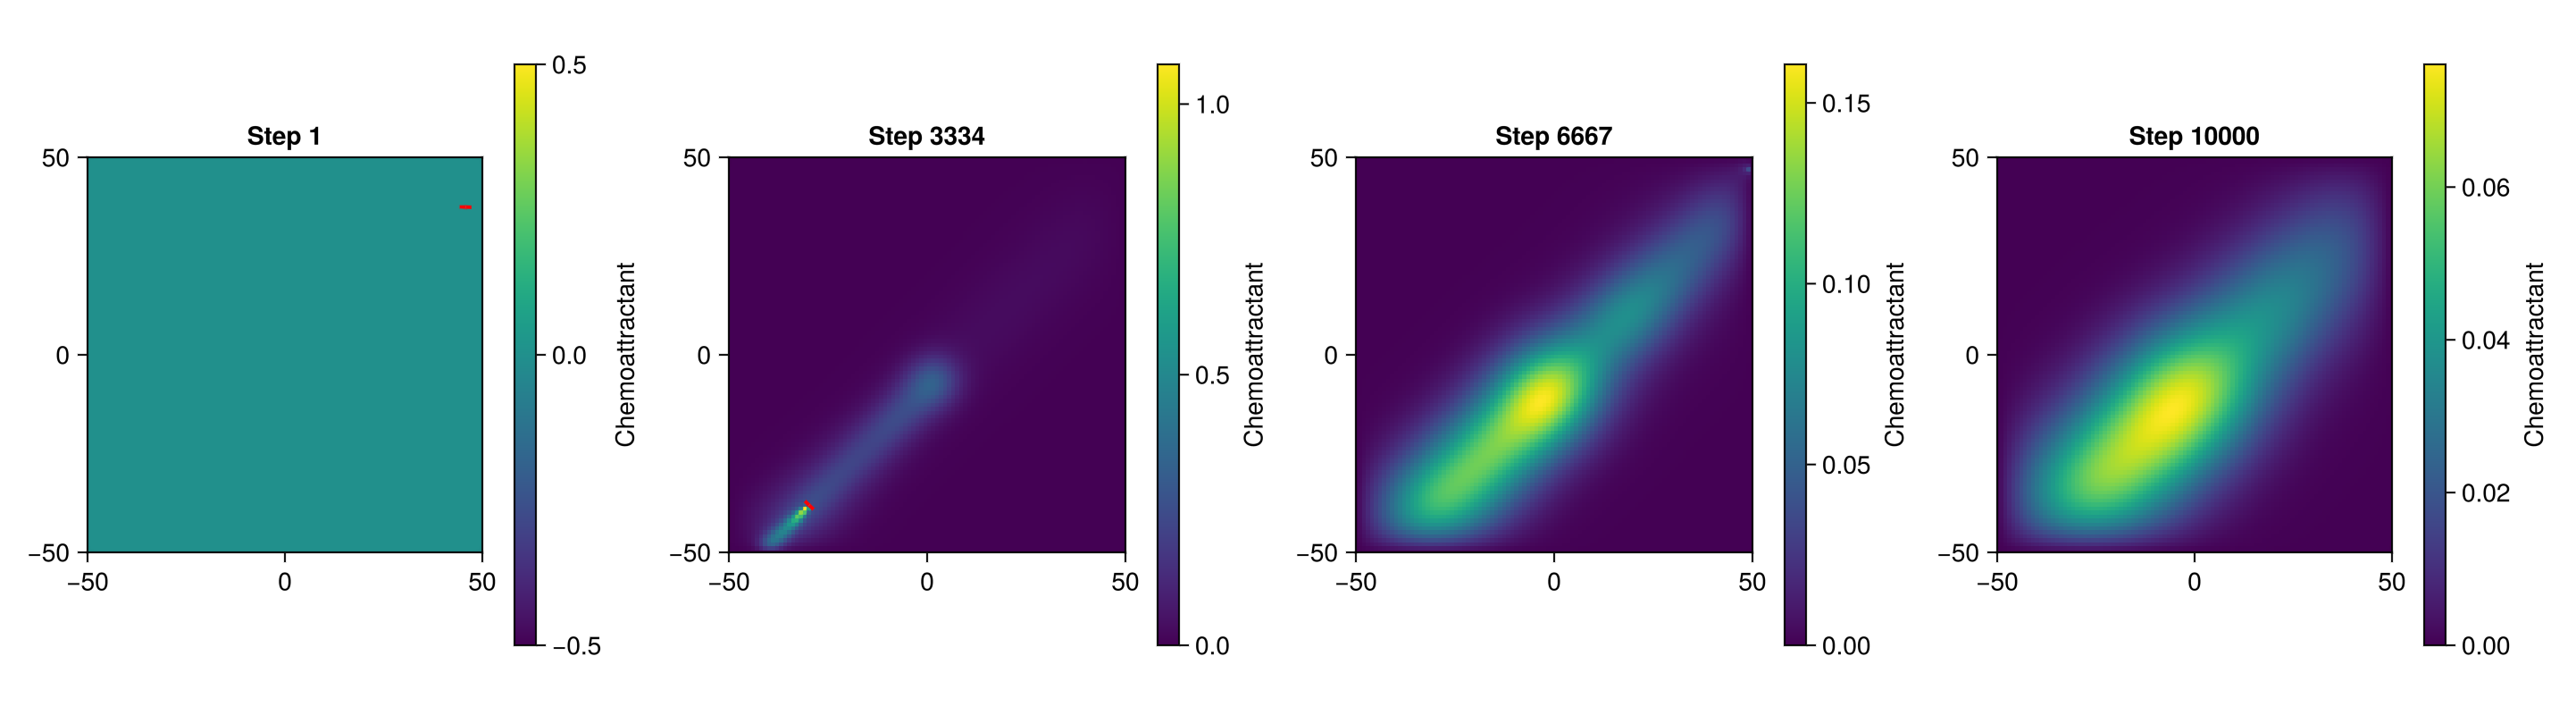

GLMakie.Screen(...)

In [144]:
steps_to_plot = unique(data.step)[1:round(Int, length(unique(data.step))/3):end]

fig = Figure(size=(1800, 400))

for (j, step) in enumerate(steps_to_plot)
    ax = Axis(fig[1, 2*j-1], aspect=1, title="Step $step")
    
    # Filter data for this step
    data_step = data[data.step .== step, :]
    
    # Extract and reshape medium grid
    mm_grid = reshape(data_step.mm_grid[1], (100, 100))
    
    # Plot heatmap

    hm = heatmap!(ax, 
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                mm_grid, 
                colormap=:viridis
                # colorrange = (0, 1.)
                )
    xlims!(ax, com.simBox[1,:]...)
    ylims!(ax, com.simBox[2,:]...)
    
    # Plot source agents
    src_mask = data_step[data_step.isSource .== true, :id]
    scatter!(ax, data_step.x[src_mask], data_step.y[src_mask], color=:cyan, markersize=2, label="Source")
    
    # Plot rods as line segments
    x = data_step.x
    y = data_step.y
    theta = data_step.theta
    l = data_step.l
    
    # Compute rod endpoints
    xs1 = x .+ l ./ 2 .* cos.(theta)
    ys1 = y .+ l ./ 2 .* sin.(theta)
    xs2 = x .- l ./ 2 .* cos.(theta)
    ys2 = y .- l ./ 2 .* sin.(theta)

    # Plot rods as line segments
    for i in 1:length(x)
        linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
        linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
    end

    # Colorbar
    Colorbar(fig[1, 2*j], hm, label="Chemoattractant")
end

# Display
display(fig)


In [25]:
save("target_S100_DM00001.png", fig)

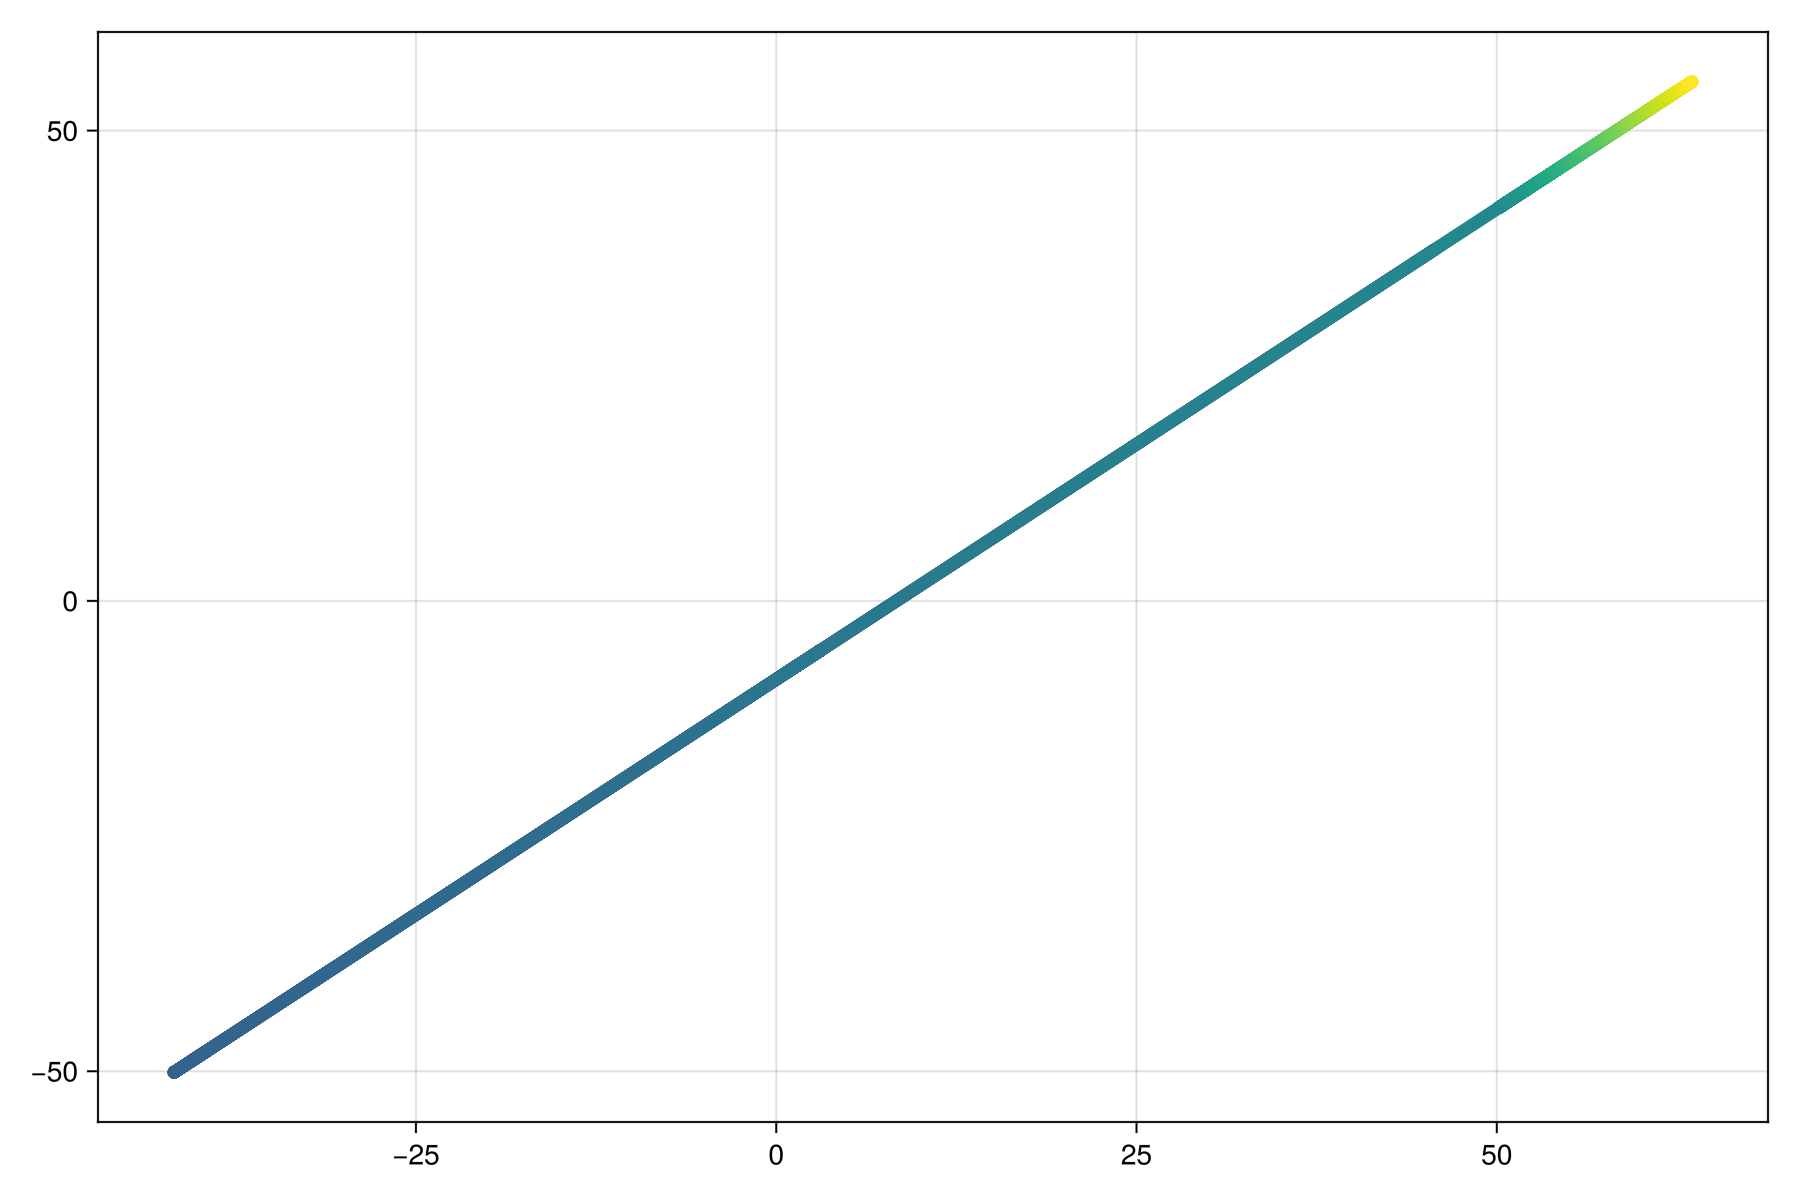

GLMakie.Screen(...)

In [145]:
fig = Figure(size=(900, 600))

ax = Axis(fig[1,1])
scatter!(ax, data.x, data.y, color = data.step)
display(fig)

In [ ]:
data_unique_times = data[data.id .== 1, :]
mm_grid = reshape(data_unique_times.mm_grid[1], (100, 100))

10000-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [94]:
# Initialize output DataFrame
df_long = DataFrame(x=Float64[], y=Float64[], t=Float64[], mm=Float64[])

# Loop over each time point
for row in eachrow(data_unique_times)
    t = row.step
    mm_flat = row.mm_grid  # 1D vector of length NMedium[1] * NMedium[2]

    # Reshape to 2D
    MM = reshape(mm_flat, 100, 100)  # y, x

    # Flatten X, Y, MM to long format
    for i in 1:100
        for j in 1:100
            push!(df_long, (x=i, y=j, t=t, mm=MM[j, i]))
        end
    end
end

In [96]:
using Pkg
Pkg.add("Interpolations")

    Updating registry at `C:\Users\ibzja\.julia\registries\General.toml`
   Resolving package versions...
    Updating `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl\Project.toml`
  [a98d9a8b] + Interpolations v0.16.2
  No Changes to `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl\Manifest.toml`


In [97]:
using Interpolations
# Get unique values
x_unique = sort(unique(df_long.x))
y_unique = sort(unique(df_long.y))
t_unique = sort(unique(df_long.t))

# Create 3D array
MM_3D = zeros(length(y_unique), length(x_unique), length(t_unique))

for row in eachrow(df_long)
    i = findfirst(isequal(row.x), x_unique)
    j = findfirst(isequal(row.y), y_unique)
    k = findfirst(isequal(row.t), t_unique)
    if !isnothing(i) && !isnothing(j) && !isnothing(k)
        MM_3D[j, i, k] = row.mm
    end
end

# Create interpolator
itp = interpolate((y_unique, x_unique, t_unique), MM_3D, (Gridded(Linear()), Gridded(Linear()), Gridded(Linear())))
scale_itp = scale(itp, y_unique, x_unique, t_unique)

UndefVarError: UndefVarError: `scale` not defined

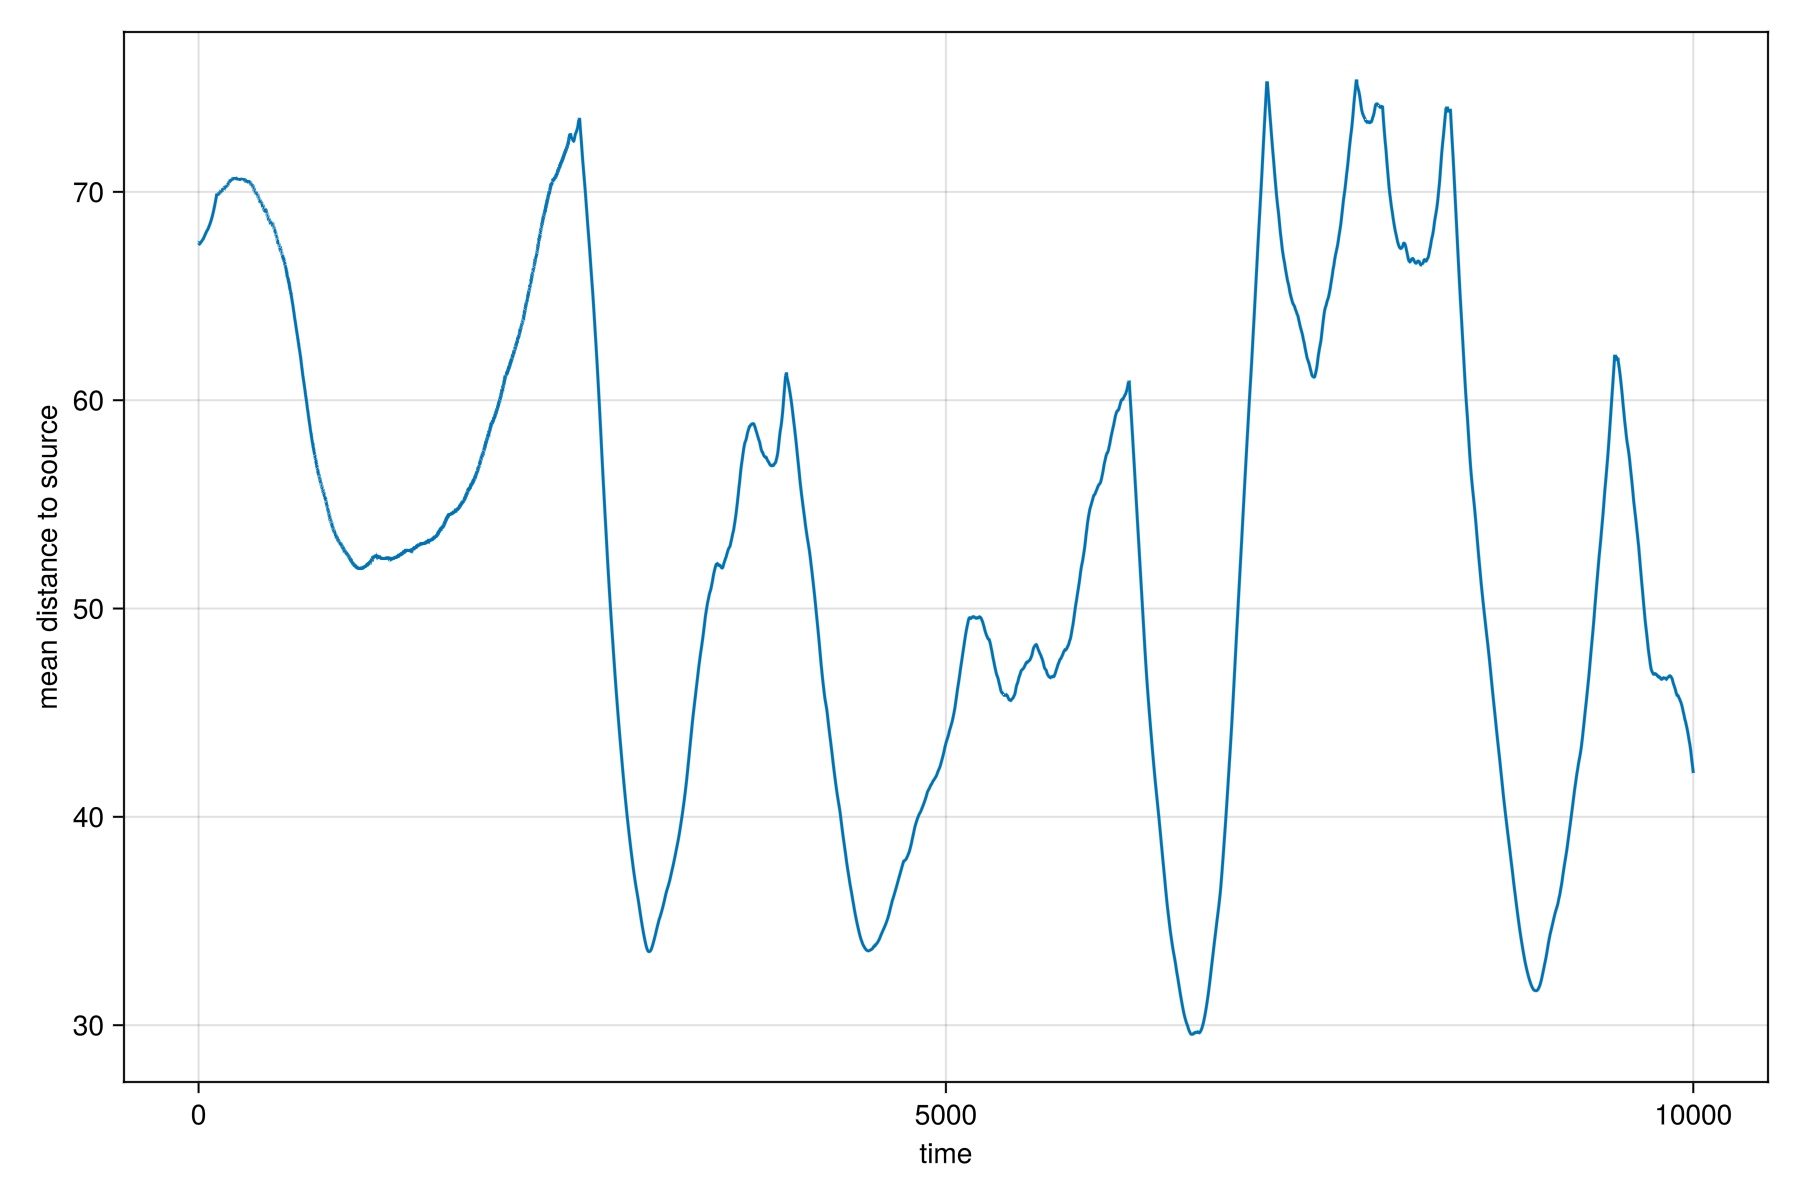

GLMakie.Screen(...)

In [74]:
# Plot mean distance to source
src_id = findfirst(data[!, :isSource][1])

mean_dist = Float64[]

for step in groupby(data, :step)

    # Source position at this step
    src = step[step.id .== src_id, :]
    isempty(src) && continue   # safety

    xs = src.x[1]
    ys = src.y[1]

    # Non-source bacteria
    others = step[step.isSource .== false, :]

    dists = sqrt.((others.x .- xs).^2 .+ (others.y .- ys).^2)

    push!(mean_dist, mean(dists))

end

fig = Figure(size=(900, 600))

ax1 = Axis(fig[1,1], xlabel="time", ylabel="mean distance to source")
lines!(ax1, unique(data[!, :step]), mean_dist)
# ax2 = Axis(fig[1,2], xlabel = "time", ylabel = "X distance")
# lines!(ax2, data[:, :step], data[:, :M])

display(fig)

In [27]:
save("target_S100_DM00001.png", fig)

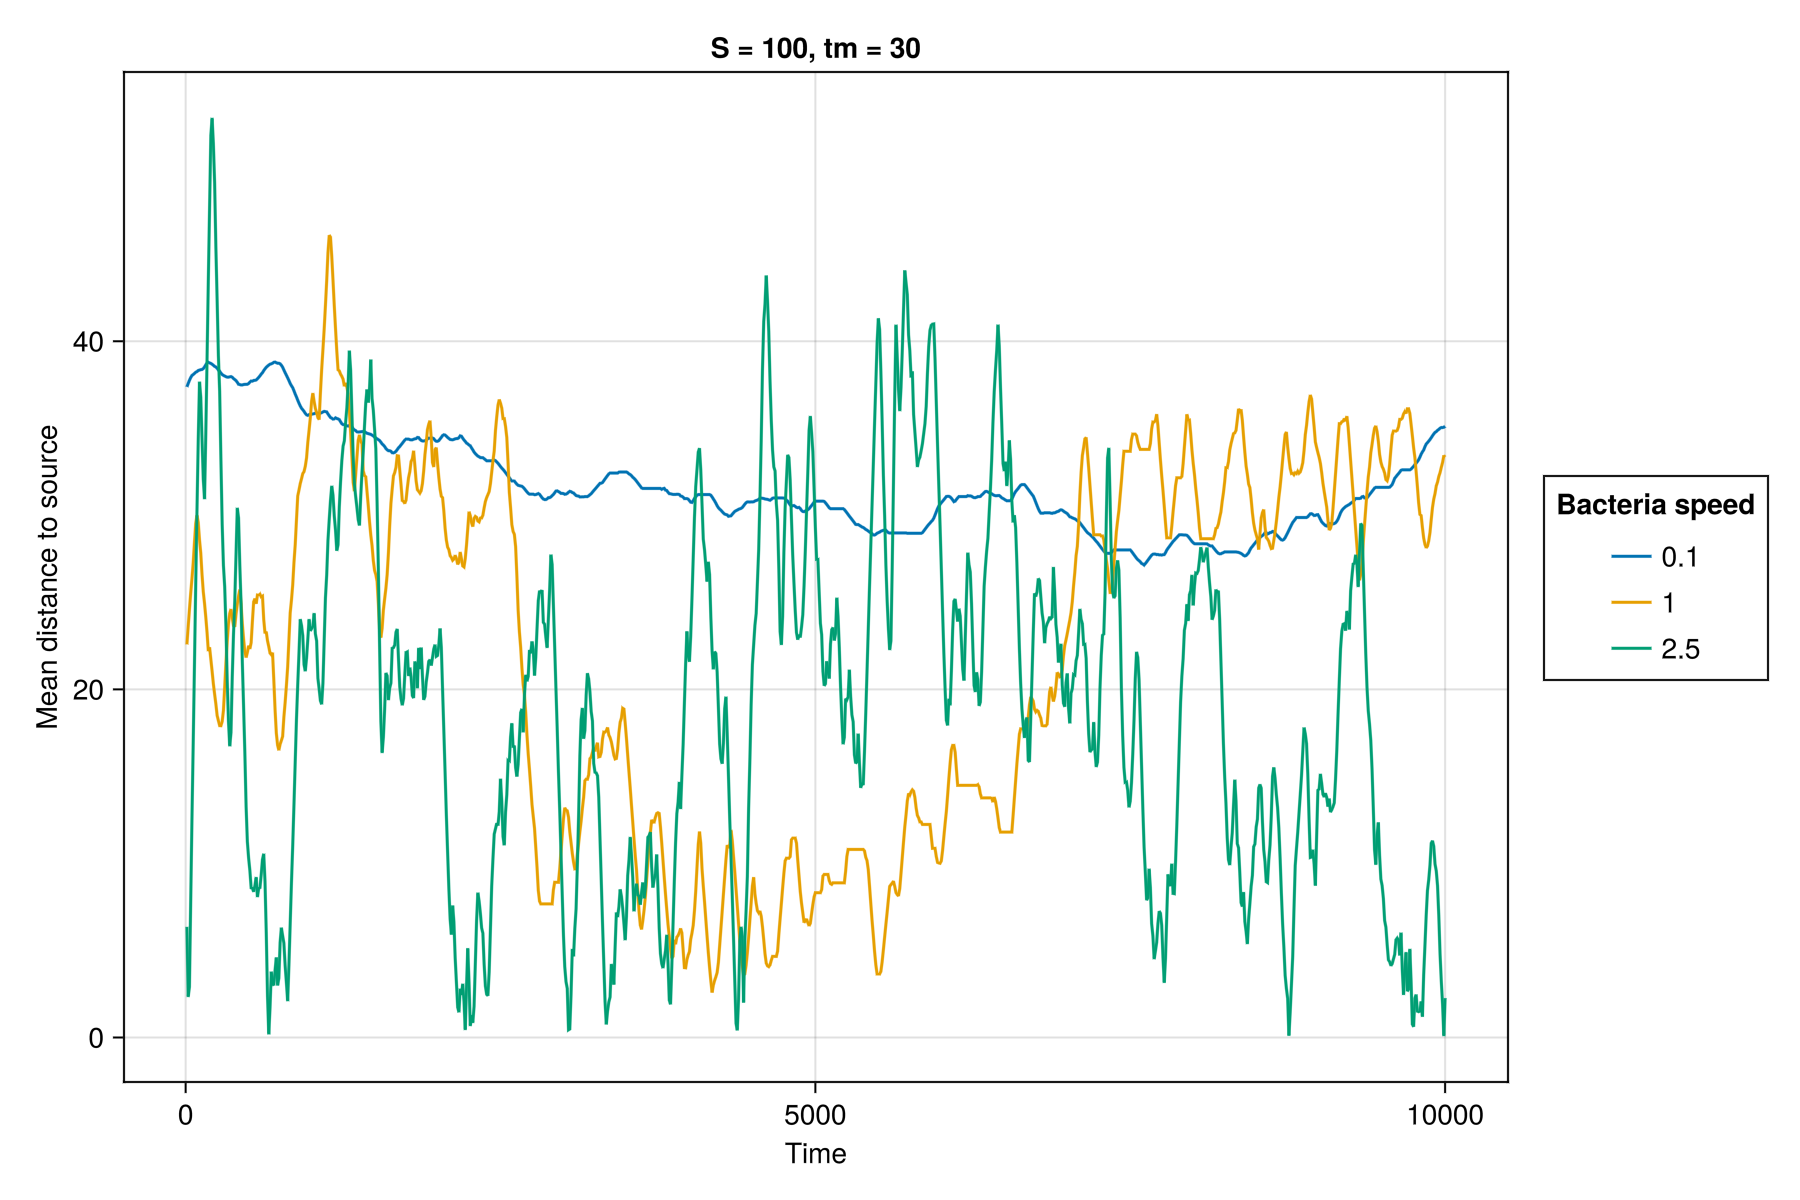

GLMakie.Screen(...)

In [45]:
fig = Figure(size=(900, 600))
dataframes = Dict{Int, DataFrame}(
    1 => CSV.read("target_SDMtm_30_V_01.csv", DataFrame),
    2 => CSV.read("target_SDMtm_30_V_1.csv", DataFrame),
    3 => CSV.read("target_S100_DM_001.csv", DataFrame)
    # 4 => CSV.read("def_DM00001.csv", DataFrame)
)

sources = Dict(
    1 => 10,
    2 => 100,
    3 => 1000
)

difusion = Dict(
    1 => 0.01,
    2 => 0.001,
    3 => 0.0001
)

adaptation_time = Dict(
    1 => 5,
    2 => 10,
    3 => 30
)

speed = Dict(
    1 => 0.1,
    2 => 1,
    3 => 2.5
    # 4 => 5
)
ax1 = Axis(fig[1,1], xlabel="Time", ylabel="Mean distance to source", title = "S = 100, tm = 30")

for i in 1:3
    data = dataframes[i]
    src_id = findfirst(data[!, :isSource][1])
    # difusion_med = difusion[i]
    # source_strength = sources[i]
    # adapt = adaptation_time[i]
    velocity = speed[i]

    mean_dist = Float64[]

    for step in groupby(data, :step)

        # Source position at this step
        src = step[step.id .== src_id, :]
        isempty(src) && continue   # safety

        xs = src.x[1]
        ys = src.y[1]

        # Non-source bacteria
        others = step[step.isSource .== false, :]

        dists = sqrt.((others.x .- xs).^2 .+ (others.y .- ys).^2)

        push!(mean_dist, mean(dists))

    end

    lines!(ax1, unique(data[!, :step]), mean_dist, label = string(velocity))

end

fig[1, 2] = Legend(fig, ax1, "Bacteria speed")

display(fig)

In [46]:
save("target_SDM_tm_compare_V.png", fig)

# Once interpolate 3D loaded

We will now model the other cells, without difusion, taking the mm from the calculated grid before. 


In [ ]:
rods2DChemotaxis = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        # :isSource => Bool, 
        # :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64         #Basa Yp leak

        # :DMedium => Float64,
        # :DSource => Float64,
        # :delta => Float64 
    ),

    # medium = Dict(
    #     :mm => Float64
    # ),

    agentODE = quote

        current_x = x
        current_y = y
        current_t = t

        mm = scale_itp(current_y, current_x, current_t)     #Agafa concentració del interpolat abans. 

        M = mm


        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = active * vx  #Change position acording to constant speed afected by forces
        dt(y) = active * vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote
      

        v_run = v
        v_tumble = 0.25 

        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 

            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
            if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                active = false
                vx = speed
                vy = speed
                theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
            else     #Si rate baixa 
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
            end

        elseif !active
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            else
                active = false
                vx = speed
                vy = speed
                theta += sqrt(2 * Dr_total * dt) * randn()
             end
        end

        if x < simBox[1,1]*0.9
            theta = rand(Uniform(0, π))  # 0 to 180° → points right
        elseif x > simBox[1,2]*0.9
            theta = rand(Uniform(π, 2π))  # 180° to 360° → points left
        elseif y < simBox[2,1]*0.9
            theta = rand(Uniform(π/2, 3π/2))  # 90° to 270° → points up
        elseif y > simBox[2,2]*0.9
            theta = rand(Uniform(-π/2, π/2))  # -90° to 90° → points down
        end
        if x < simBox[1,1]*0.9 || x > simBox[1,2]*0.9 || y < simBox[2,1]*0.9 || y > simBox[2,2]*0.9
            x = clamp(x, simBox[1,1]*0.9 + 0.01, simBox[1,2]*0.9 - 0.01)
            y = clamp(y, simBox[2,1]*0.9 + 0.01, simBox[2,2]*0.9 - 0.01)
        end

    end,

    # mediumODE = quote
    #     if @mediumInside()
    #         dt(mm) = DMedium *(@∂2(1, mm)+ @∂2(2, mm)) - delta*mm 
    #     elseif @mediumBorder(1,-1)
    #         mm = 0
    #     elseif @mediumBorder(1,1)
    #         mm = 0
    #     elseif @mediumBorder(2,-1)
    #         mm = 0
    #     elseif @mediumBorder(2,-1)
    #         mm = 0
    #     end
    # end,

    neighborsAlg = CBMNeighbors.CellLinked(cellEdge = 4)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	active (Bool agent)
	v (Float64 agent)
	λ (Float64 agent)
	F (Float64 agent)
	fx (Float64 agent)
	A (Float64 agent)
	methyl (Float64 agent)
	vx (Float64 agent)
	l (Float64 agent)
	m (Float64 agent)
	fy (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 begin
    v_run = v
    v_tumble = 0.25
    speed = if active
            v_run
        else
            v_tumble
        end
    Dr_tumble = 6.2
    Dr_total = if active
            Dr_run
      